# Halo Occupation Distribution (HOD) Analysis
Compute $\langle N_{\mathrm{gal}} | M_{\mathrm{halo}} \rangle$ from GALFORM galaxies.hdf5 outputs using merger-tree halo IDs.

## Import Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir, DEFAULT_HALO_MASS_BINS
from galform_analysis.analysis.mass_functions import (
    hod_given_redshift_and_subvolume,
    hods_given_redshifts_and_subvolume,
    avg_hod_given_redshift_and_subvolumes,
    avg_hod_given_redshifts_and_subvolume,
 )

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = Path(get_base_dir())

## HOD for a single redshift and subvolume

In [2]:
example_snapshot = "iz207"
example_ivol = 40
galaxy_stellar_mass_min = 1e9  # Msun/h

hod_result = hod_given_redshift_and_subvolume(
    base_dir / example_snapshot,
    example_ivol,
    bins=DEFAULT_HALO_MASS_BINS,
    galaxy_stellar_mass_min=galaxy_stellar_mass_min,
    halo_mass_lower_limit=None,
 )

print(
    f"Loaded HOD for {hod_result['iz']} (z={hod_result['z']:.3f}), ivol={hod_result['ivol']}; ",
    f"N_halos={hod_result['n_halos']}, N_gal={hod_result['n_galaxies']}.",
 )

Loaded HOD for iz207 (z=0.496), ivol=40;  N_halos=1089, N_gal=5054.


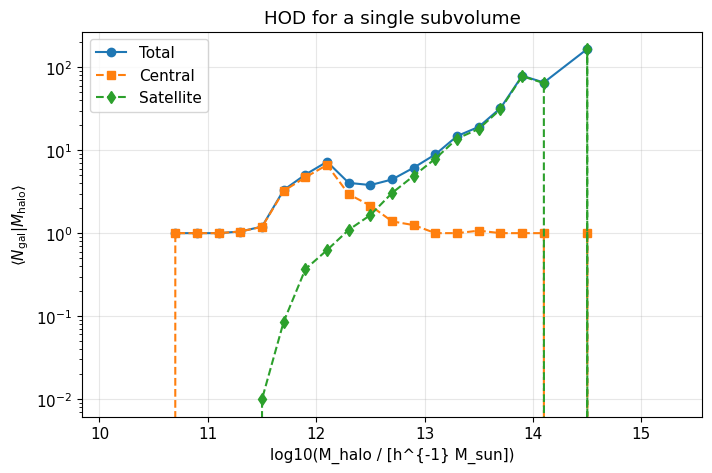

In [3]:
centers = hod_result['centers']
mean_occ = hod_result['mean_occupation']
mean_cen = hod_result['mean_central']
mean_sat = hod_result['mean_satellite']

valid = np.isfinite(mean_occ) & (mean_occ > 0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers[valid], mean_occ[valid], 'o-', label='Total')

if mean_cen is not None:
    valid_cen = np.isfinite(mean_cen) & (mean_cen >= 0)
    ax.plot(centers[valid_cen], mean_cen[valid_cen], 's--', label='Central')
if mean_sat is not None:
    valid_sat = np.isfinite(mean_sat) & (mean_sat >= 0)
    ax.plot(centers[valid_sat], mean_sat[valid_sat], 'd--', label='Satellite')

ax.set_yscale('log')
ax.set_xlabel("log10(M_halo / [h^{-1} M_sun])")
ax.set_ylabel(r"$\langle N_{\mathrm{gal}} | M_{\mathrm{halo}} \rangle$")
ax.set_title("HOD for a single subvolume")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## HOD across multiple redshifts (fixed subvolume)

In [4]:
example_ivol = 40
iz_nums = [82, 100, 120]

multi_hod = hods_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    base_dir=base_dir,
    galaxy_stellar_mass_min=galaxy_stellar_mass_min,
    halo_mass_lower_limit=None,
 )

hod_df, results_by_z = multi_hod
print(f"Loaded {len(results_by_z)} snapshots for ivol={example_ivol}")

Loaded 3 snapshots for ivol=40


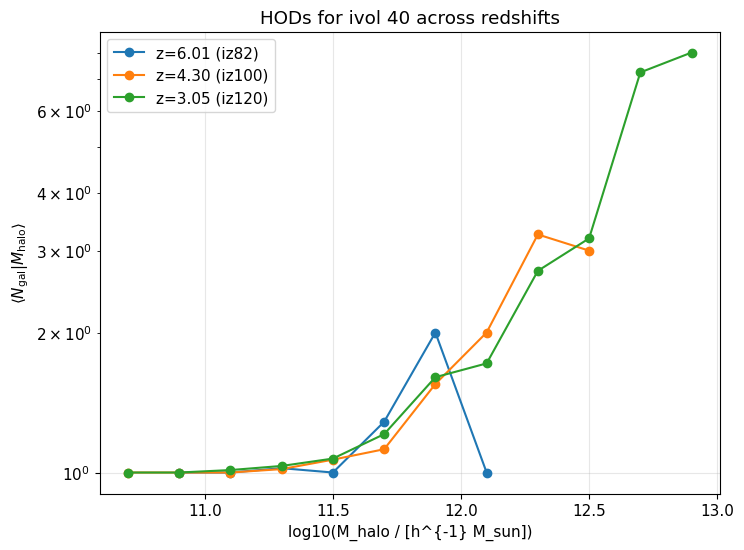

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_yscale('log')
for res in results_by_z:
    centers = res['centers']
    mean_occ = res['mean_occupation']
    valid = np.isfinite(mean_occ) & (mean_occ > 0)
    ax.plot(centers[valid], mean_occ[valid], 'o-', label=f"z={res['z']:.2f} ({res['iz']})")

ax.set_xlabel("log10(M_halo / [h^{-1} M_sun])")
ax.set_ylabel(r"$\langle N_{\mathrm{gal}} | M_{\mathrm{halo}} \rangle$")
ax.set_title(f"HODs for ivol {example_ivol} across redshifts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Average HOD for multiple subvolumes (fixed redshift)

In [6]:
test_ivols = [0, 1, 2, 3, 4]
test_iz = 207

hod_combined = avg_hod_given_redshift_and_subvolumes(
    iz_num=test_iz,
    ivols=test_ivols,
    galaxy_stellar_mass_min=galaxy_stellar_mass_min,
    halo_mass_lower_limit=None,
 )

print(f"Combined {hod_combined['n_used']} subvolumes for iz{test_iz}")
print(f"Total halos used: {hod_combined['n_halos']}")
print(f"Total galaxies used: {hod_combined['n_galaxies']}")

Combined 5 subvolumes for iz207
Total halos used: 5389
Total galaxies used: 25527


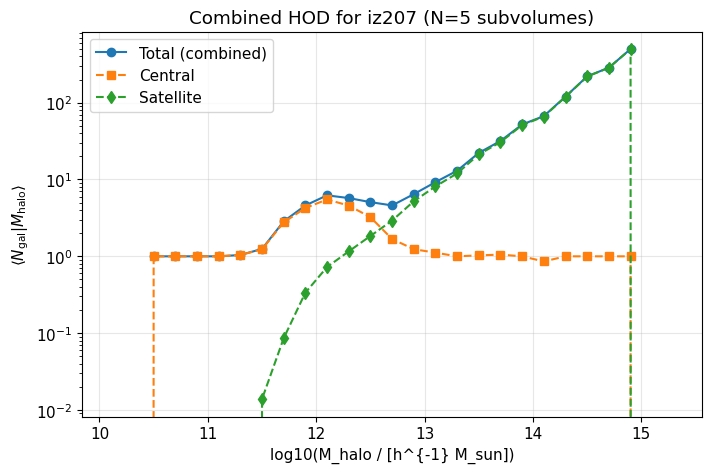

In [7]:
centers = hod_combined['centers']
mean_occ = hod_combined['mean_occupation']
mean_cen = hod_combined['mean_central']
mean_sat = hod_combined['mean_satellite']

valid = np.isfinite(mean_occ) & (mean_occ > 0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers[valid], mean_occ[valid], 'o-', label='Total (combined)')

if mean_cen is not None:
    valid_cen = np.isfinite(mean_cen) & (mean_cen >= 0)
    ax.plot(centers[valid_cen], mean_cen[valid_cen], 's--', label='Central')
if mean_sat is not None:
    valid_sat = np.isfinite(mean_sat) & (mean_sat >= 0)
    ax.plot(centers[valid_sat], mean_sat[valid_sat], 'd--', label='Satellite')

ax.set_yscale('log')
ax.set_xlabel("log10(M_halo / [h^{-1} M_sun])")
ax.set_ylabel(r"$\langle N_{\mathrm{gal}} | M_{\mathrm{halo}} \rangle$")
ax.set_title(f"Combined HOD for iz{test_iz} (N={len(test_ivols)} subvolumes)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Average HOD for a fixed subvolume across redshifts

In [8]:
example_ivol = 40
iz_nums = [82, 100, 120]

avg_hod = avg_hod_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    galaxy_stellar_mass_min=galaxy_stellar_mass_min,
    halo_mass_lower_limit=None,
 )

print(
    f"Used {avg_hod['n_used']}/{avg_hod['n_requested']} snapshots",
    f"ivol={avg_hod['ivol']}",
    f"z range: {min(avg_hod['z_list']):.2f}-{max(avg_hod['z_list']):.2f}",
    sep='; '
 )

Used 3/3 snapshots; ivol=40; z range: 3.05-6.01


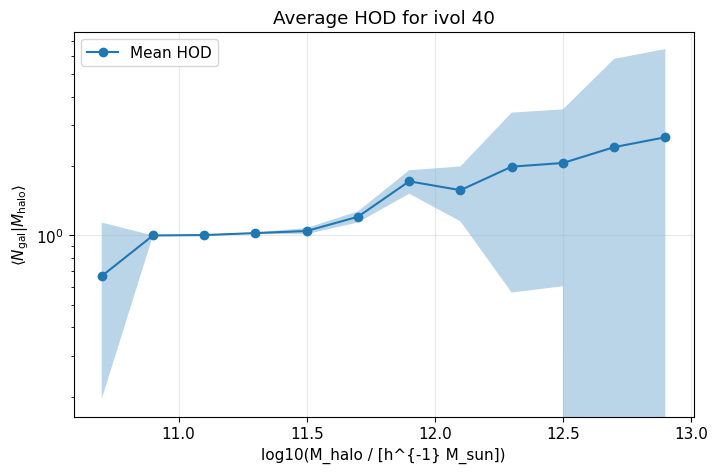

In [9]:
centers = avg_hod['centers']
mean_occ = avg_hod['mean_occupation']
mean_occ_std = avg_hod['mean_occupation_std']

valid = np.isfinite(mean_occ) & (mean_occ > 0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers[valid], mean_occ[valid], 'o-', label='Mean HOD')
ax.fill_between(
    centers[valid],
    (mean_occ - mean_occ_std)[valid],
    (mean_occ + mean_occ_std)[valid],
    alpha=0.3,
 )

ax.set_yscale('log')
ax.set_xlabel("log10(M_halo / [h^{-1} M_sun])")
ax.set_ylabel(r"$\langle N_{\mathrm{gal}} | M_{\mathrm{halo}} \rangle$")
ax.set_title(f"Average HOD for ivol {example_ivol}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()